In [1]:
print("a")

a


In [2]:
import numpy as np
from scipy.special import erfc
from itertools import product
 
def Fhit_function(radius, distance, diffusionCoef, t):
    """Calculates the cumulative hitting probability up to time t."""
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))
 
def bit_error_rate(mem_len, threshold, N, radius, distance, diffusionCoef, Ts):
    """
    Calculates the Bit Error Rate (BER) accounting for Inter-Symbol Interference (ISI)
    using a Gaussian approximation.
   
    Parameters:
    - mem_len: Total length of the bit sequence to consider (current bit + previous bits)
    - threshold: The decision threshold (number of molecules)
    - N: Number of molecules released for bit '1'
    - radius: Radius of the receiver
    - distance: Distance between transmitter and receiver
    - diffusionCoef: Diffusion coefficient
    - Ts: Symbol duration (time allocated per bit)
    """
   
    # 1. Calculate interval hitting probabilities (Channel Coefficients)
    # P[0] is probability of hitting in the current slot [0, Ts]
    # P[1] is hitting in [Ts, 2Ts], representing ISI from the previous bit, etc.
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(radius, distance, diffusionCoef, t_start)
       
    total_ber = 0.0
    num_sequences = 2**mem_len
   
    # 2. Generate all possible bit sequences of length mem_len
    sequences = list(product([0, 1], repeat=mem_len))
   
    for seq in sequences:
        # Reverse sequence so seq_rev[0] is the current bit, seq_rev[1] is the previous bit, etc.
        seq_rev = seq[::-1]
        current_bit = seq_rev[0]
       
        # 3. Calculate Mean and Variance for this specific sequence
        mu = 0.0
        variance = 0.0
        for i in range(mem_len):
            bit = seq_rev[i]
            mu += bit * N * P[i]
            # Variance of a sum of independent Binomials: np(1-p)
            variance += bit * N * P[i] * (1 - P[i])
           
        std = np.sqrt(variance)
       
        # 4. Calculate Conditional Error Probability using Gaussian Q-function equivalent
        # Q(x) = 0.5 * erfc(x / sqrt(2))
        if std == 0:
            # Edge case: If sequence is all zeros, there are no molecules, hence no variance.
            if current_bit == 1:
                pe = 1.0 if mu < threshold else 0.0
            else:
                pe = 1.0 if mu >= threshold else 0.0
        else:
            if current_bit == 1:
                # True bit is 1, error if received signal < threshold
                pe = 0.5 * erfc((mu - threshold) / (std * np.sqrt(2)))
            else:
                # True bit is 0, error if received signal > threshold
                pe = 0.5 * erfc((threshold - mu) / (std * np.sqrt(2)))
               
        total_ber += pe
       
    # 5. Average the error probabilities across all possible sequences
    average_ber = total_ber / num_sequences
   
    return average_ber
 
# --- Example Usage ---
# Assuming your physical parameters from the previous script:
p_radius = 5
p_distance = 12.5 - p_radius  # Distance from point source to receiver surface
p_diffusionCoef = 79.4
N_molecules = 10**6
 
# New digital communication parameters
symbol_duration = 1  # Ts in seconds
decision_threshold = 20000  # Arbitrary threshold for decoding
memory_length = 5  # 5-bit sequence (current bit + 4 previous bits)
 
ber = bit_error_rate(
    mem_len=memory_length,
    threshold=decision_threshold,
    N=N_molecules,
    radius=p_radius,
    distance=p_distance,
    diffusionCoef=p_diffusionCoef,
    Ts=symbol_duration
)
 
print(f"Calculated BER for memory length {memory_length}: {ber}")

Calculated BER for memory length 5: 0.40625


In [3]:
# Parameter lists for simulation sweep
import pandas as pd
from itertools import product

# Define parameter ranges
param_ranges = {
    'p_radius': [3, 5, 7],
    'p_distance': [7.5, 12.5, 15],  # Will calculate based on radius
    'p_diffusionCoef': [50, 79.4, 100],
    'N_molecules': [1e5, 1e6, 1e7],
    'symbol_duration': [0.5, 1, 2],
    'decision_threshold': [10000, 20000, 50000],
    'memory_length': [3, 5, 7]
}

# Create a list of parameter combinations
# For now, let's create a simpler approach: individual parameter lists
p_radius_list = [3, 5, 7]
p_diffusionCoef_list = [50, 79.4, 100]
N_molecules_list = [1e5, 1e6, 1e7]
symbol_duration_list = [0.5, 1, 2]
decision_threshold_list = [10000, 20000, 50000]
memory_length_list = [3, 5, 7]

# Create results storage
results = []

print("Parameter lists defined:")
print(f"  p_radius: {p_radius_list}")
print(f"  p_diffusionCoef: {p_diffusionCoef_list}")
print(f"  N_molecules: {N_molecules_list}")
print(f"  symbol_duration: {symbol_duration_list}")
print(f"  decision_threshold: {decision_threshold_list}")
print(f"  memory_length: {memory_length_list}")

Parameter lists defined:
  p_radius: [3, 5, 7]
  p_diffusionCoef: [50, 79.4, 100]
  N_molecules: [100000.0, 1000000.0, 10000000.0]
  symbol_duration: [0.5, 1, 2]
  decision_threshold: [10000, 20000, 50000]
  memory_length: [3, 5, 7]


In [4]:
# Run simulations with parameter sweep
import time

total_simulations = (len(p_radius_list) * len(p_diffusionCoef_list) * 
                    len(N_molecules_list) * len(symbol_duration_list) * 
                    len(decision_threshold_list) * len(memory_length_list))

print(f"Total simulations to run: {total_simulations}")
print("Starting parameter sweep...")

start_time = time.time()
sim_count = 0

# Iterate through all parameter combinations
for radius in p_radius_list:
    for diffusion in p_diffusionCoef_list:
        for n_mol in N_molecules_list:
            for symbol_dur in symbol_duration_list:
                for threshold in decision_threshold_list:
                    for mem_len in memory_length_list:
                        # Calculate distance from radius
                        distance = 12.5 - radius
                        
                        # Run BER calculation
                        try:
                            ber = bit_error_rate(
                                mem_len=mem_len,
                                threshold=int(threshold),
                                N=int(n_mol),
                                radius=radius,
                                distance=distance,
                                diffusionCoef=diffusion,
                                Ts=symbol_dur
                            )
                            
                            # Store results
                            results.append({
                                'p_radius': radius,
                                'p_distance': distance,
                                'p_diffusionCoef': diffusion,
                                'N_molecules': int(n_mol),
                                'symbol_duration': symbol_dur,
                                'decision_threshold': int(threshold),
                                'memory_length': mem_len,
                                'BER': ber
                            })
                            
                            sim_count += 1
                            if sim_count % 10 == 0:
                                print(f"  Completed {sim_count}/{total_simulations} simulations...")
                        
                        except Exception as e:
                            print(f"Error at iteration {sim_count}: {e}")
                            continue

elapsed_time = time.time() - start_time
print(f"\nCompleted {sim_count} simulations in {elapsed_time:.2f} seconds")
print(f"Average time per simulation: {elapsed_time/sim_count:.4f} seconds")

Total simulations to run: 729
Starting parameter sweep...
  Completed 10/729 simulations...
  Completed 20/729 simulations...
  Completed 30/729 simulations...
  Completed 40/729 simulations...
  Completed 50/729 simulations...
  Completed 60/729 simulations...
  Completed 70/729 simulations...
  Completed 80/729 simulations...
  Completed 90/729 simulations...
  Completed 100/729 simulations...
  Completed 110/729 simulations...
  Completed 120/729 simulations...
  Completed 130/729 simulations...
  Completed 140/729 simulations...
  Completed 150/729 simulations...
  Completed 160/729 simulations...
  Completed 170/729 simulations...
  Completed 180/729 simulations...
  Completed 190/729 simulations...
  Completed 200/729 simulations...
  Completed 210/729 simulations...
  Completed 220/729 simulations...
  Completed 230/729 simulations...
  Completed 240/729 simulations...
  Completed 250/729 simulations...
  Completed 260/729 simulations...
  Completed 270/729 simulations...
  Comp

In [5]:
# Convert results to DataFrame and save
df_results = pd.DataFrame(results)

print(f"Results DataFrame shape: {df_results.shape}")
print("\nFirst few rows:")
print(df_results.head(10))

print("\nResults summary statistics:")
print(df_results[['BER']].describe())

# Save to CSV
output_file = 'ber_simulation_results.csv'
df_results.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

Results DataFrame shape: (729, 8)

First few rows:
   p_radius  p_distance  p_diffusionCoef  N_molecules  symbol_duration  \
0         3         9.5             50.0       100000              0.5   
1         3         9.5             50.0       100000              0.5   
2         3         9.5             50.0       100000              0.5   
3         3         9.5             50.0       100000              0.5   
4         3         9.5             50.0       100000              0.5   
5         3         9.5             50.0       100000              0.5   
6         3         9.5             50.0       100000              0.5   
7         3         9.5             50.0       100000              0.5   
8         3         9.5             50.0       100000              0.5   
9         3         9.5             50.0       100000              1.0   

   decision_threshold  memory_length       BER  
0               10000              3  0.375000  
1               10000              5

In [6]:
# Analysis and filtering examples

# Find the best (lowest) BER
best_result = df_results.loc[df_results['BER'].idxmin()]
print("Best Configuration (Lowest BER):")
print(best_result)
print(f"\nBER: {best_result['BER']:.6e}\n")

# Filter results by criteria
print("=" * 60)
print("Example filters:\n")

# Results with BER < 0.001
low_ber = df_results[df_results['BER'] < 0.001]
print(f"Configurations with BER < 0.001: {len(low_ber)}")

# Results for specific memory length
mem_len_5 = df_results[df_results['memory_length'] == 5]
print(f"Configurations with memory_length=5: {len(mem_len_5)}")

# Group by memory length and show average BER
print("\nAverage BER by Memory Length:")
print(df_results.groupby('memory_length')['BER'].agg(['mean', 'min', 'max']))

print("\nAverage BER by Diffusion Coefficient:")
print(df_results.groupby('p_diffusionCoef')['BER'].agg(['mean', 'min', 'max']))

print("\nAverage BER by Decision Threshold:")
print(df_results.groupby('decision_threshold')['BER'].agg(['mean', 'min', 'max']))

Best Configuration (Lowest BER):
p_radius                   3.0
p_distance                 9.5
p_diffusionCoef           79.4
N_molecules           100000.0
symbol_duration            2.0
decision_threshold     10000.0
memory_length              3.0
BER                        0.0
Name: 99, dtype: float64

BER: 0.000000e+00

Example filters:

Configurations with BER < 0.001: 93
Configurations with memory_length=5: 243

Average BER by Memory Length:
                   mean  min  max
memory_length                    
3              0.301855  0.0  0.5
5              0.353610  0.0  0.5
7              0.371012  0.0  0.5

Average BER by Diffusion Coefficient:
                     mean  min  max
p_diffusionCoef                    
50.0             0.356540  0.0  0.5
79.4             0.340072  0.0  0.5
100.0            0.329865  0.0  0.5

Average BER by Decision Threshold:
                        mean  min       max
decision_threshold                         
10000               0.310466  0.0  

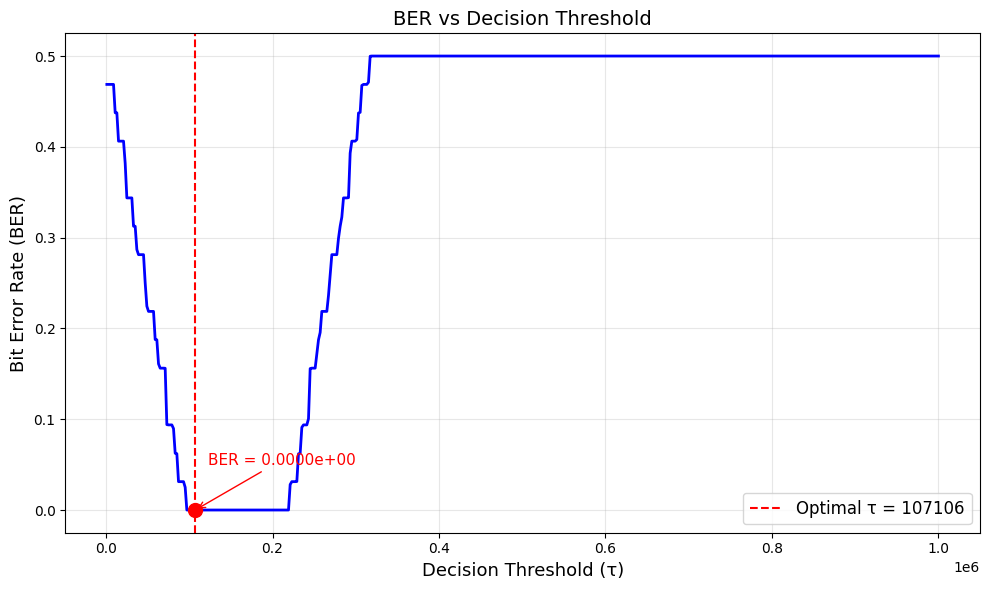

Optimal threshold: 107106 molecules
Minimum BER: 0.000000e+00


In [ ]:
import matplotlib.pyplot as plt

# --- BER vs Threshold sweep ---
# Default physical parameters
p_radius = 5
p_distance = 12.5 - p_radius
p_diffusionCoef = 79.4
N_molecules = 10**6
symbol_duration = 1
memory_length = 5

# Fine threshold sweep
thresholds = np.linspace(1000, 1000000, 500)
ber_values = [
    bit_error_rate(memory_length, th, N_molecules, p_radius, p_distance, p_diffusionCoef, symbol_duration)
    for th in thresholds
]

# Find optimal threshold
opt_idx = np.argmin(ber_values)
opt_threshold = thresholds[opt_idx]
opt_ber = ber_values[opt_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, ber_values, 'b-', linewidth=2)
ax.axvline(opt_threshold, color='r', linestyle='--', linewidth=1.5, label=f'Optimal τ = {opt_threshold:.0f}')
ax.plot(opt_threshold, opt_ber, 'ro', markersize=10, zorder=5)
ax.set_xlabel('Decision Threshold (τ)', fontsize=13)
ax.set_ylabel('Bit Error Rate (BER)', fontsize=13)
ax.set_title('BER vs Decision Threshold', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.annotate(f'BER = {opt_ber:.4e}', xy=(opt_threshold, opt_ber),
            xytext=(opt_threshold + 15000, opt_ber + 0.05),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {opt_threshold:.0f} molecules")
print(f"Minimum BER: {opt_ber:.6e}")

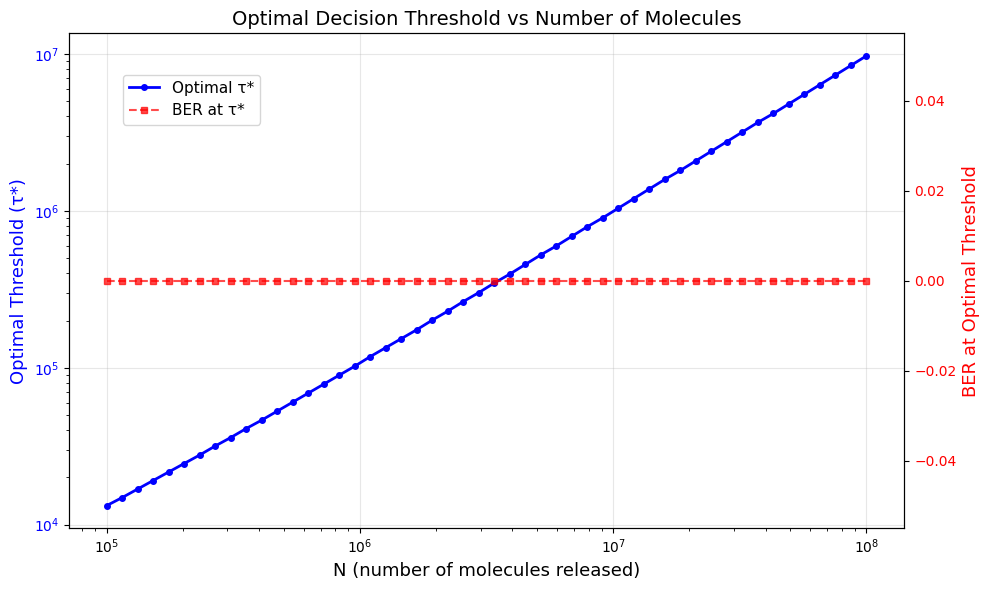

           N      Optimal τ*      τ*/N           BER
----------------------------------------------------
      100000           13227    0.1323    0.0000e+00
      115139           14883    0.1293    0.0000e+00
      132571           16871    0.1273    0.0000e+00
      152641           19119    0.1253    0.0000e+00
      175751           21661    0.1233    0.0000e+00
      202358           24535    0.1212    0.0000e+00
      232995           27783    0.1192    0.0000e+00
      268269           31720    0.1182    0.0000e+00
      308884           35903    0.1162    0.0000e+00
      355648           40982    0.1152    0.0000e+00
      409491           46366    0.1132    0.0000e+00
      471486           52913    0.1122    0.0000e+00
      542867           60380    0.1112    0.0000e+00
      625055           68895    0.1102    0.0000e+00
      719685           78604    0.1092    0.0000e+00
      828642           89673    0.1082    0.0000e+00
      954095          102294    0.1072    0.00

In [14]:
# --- Optimal Threshold vs N (number of molecules) ---
p_radius = 5
p_distance = 12.5 - p_radius
p_diffusionCoef = 79.4
symbol_duration = 1
memory_length = 5

# Range of N values (log-spaced for wide coverage)
N_values = np.logspace(5, 8, 50).astype(int)  # 10^4 to 10^8

optimal_thresholds = []
optimal_bers = []

for N in N_values:
    # Threshold sweep scaled to N (optimal threshold scales with N)
    th_range = np.linspace(1, N * 0.5, 500)
    bers = [bit_error_rate(memory_length, th, N, p_radius, p_distance, p_diffusionCoef, symbol_duration)
            for th in th_range]
    opt_i = np.argmin(bers)
    optimal_thresholds.append(th_range[opt_i])
    optimal_bers.append(bers[opt_i])

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(N_values, optimal_thresholds, 'b-o', markersize=4, linewidth=2)
ax1.set_xlabel('N (number of molecules released)', fontsize=13)
ax1.set_ylabel('Optimal Threshold (τ*)', fontsize=13, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_title('Optimal Decision Threshold vs Number of Molecules', fontsize=14)

# Secondary y-axis: show the BER at optimal threshold
ax2 = ax1.twinx()
ax2.plot(N_values, optimal_bers, 'r--s', markersize=4, linewidth=1.5, alpha=0.7)
ax2.set_ylabel('BER at Optimal Threshold', fontsize=13, color='r')
ax2.tick_params(axis='y', labelcolor='r')

fig.legend(['Optimal τ*', 'BER at τ*'], loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=11)
plt.tight_layout()
plt.show()

# Print table
print(f"{'N':>12s}  {'Optimal τ*':>14s}  {'τ*/N':>8s}  {'BER':>12s}")
print("-" * 52)
for n, th, ber in zip(N_values, optimal_thresholds, optimal_bers):
    print(f"{n:>12d}  {th:>14.0f}  {th/n:>8.4f}  {ber:>12.4e}")


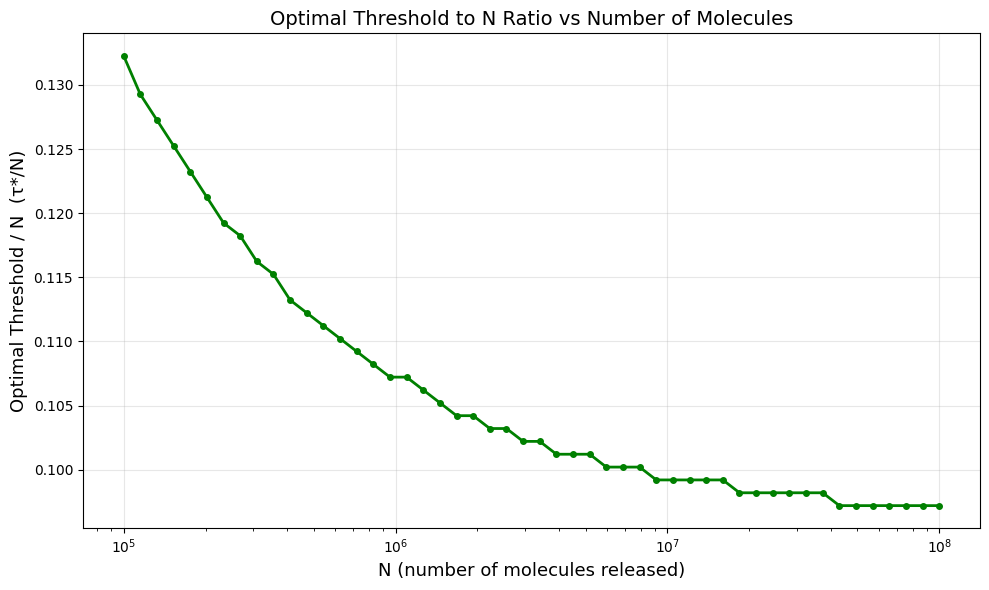

In [16]:
# --- Optimal Threshold / N ratio vs N ---
fig, ax = plt.subplots(figsize=(10, 6))

ratios = [th / n for th, n in zip(optimal_thresholds, N_values)]

ax.plot(N_values, ratios, 'g-o', markersize=4, linewidth=2)
ax.set_xlabel('N (number of molecules released)', fontsize=13)
ax.set_ylabel('Optimal Threshold / N  (τ*/N)', fontsize=13)
ax.set_xscale('log')
ax.set_title('Optimal Threshold to N Ratio vs Number of Molecules', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

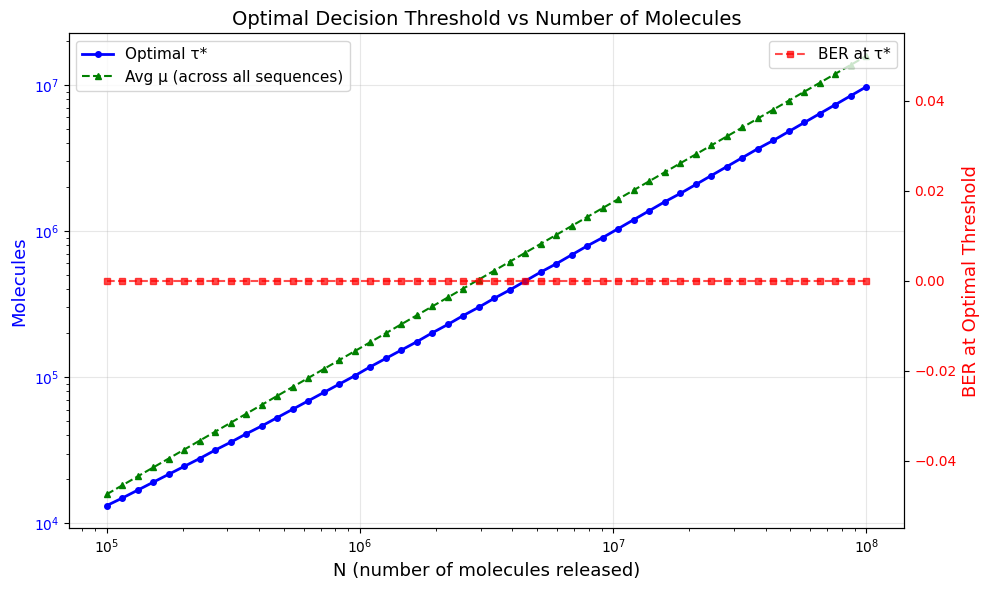

           N           Avg μ      Optimal τ*      τ*/μ           BER
--------------------------------------------------------------------
      100000           15802           13227    0.8370    0.0000e+00
      115139           18195           14883    0.8180    0.0000e+00
      132571           20949           16871    0.8053    0.0000e+00
      152641           24121           19119    0.7926    0.0000e+00
      175751           27773           21661    0.7800    0.0000e+00
      202358           31977           24535    0.7673    0.0000e+00
      232995           36818           27783    0.7546    0.0000e+00
      268269           42393           31720    0.7482    0.0000e+00
      308884           48811           35903    0.7356    0.0000e+00
      355648           56200           40982    0.7292    0.0000e+00
      409491           64709           46366    0.7165    0.0000e+00
      471486           74505           52913    0.7102    0.0000e+00
      542867           85785      

In [18]:
# --- Optimal Threshold vs N (number of molecules) ---
p_radius = 5
p_distance = 12.5 - p_radius
p_diffusionCoef = 79.4
symbol_duration = 1
memory_length = 5

# Range of N values (log-spaced for wide coverage)
N_values = np.logspace(5, 8, 50).astype(int)

optimal_thresholds = []
optimal_bers = []
avg_mu_values = []

for N in N_values:
    # Calculate interval hitting probabilities
    P = np.zeros(memory_length)
    for i in range(memory_length):
        t_end = (i + 1) * symbol_duration
        t_start = i * symbol_duration
        P[i] = Fhit_function(p_radius, p_distance, p_diffusionCoef, t_end) - Fhit_function(p_radius, p_distance, p_diffusionCoef, t_start)

    # Average mu across all possible bit sequences
    sequences = list(product([0, 1], repeat=memory_length))
    total_mu = 0.0
    for seq in sequences:
        seq_rev = seq[::-1]
        mu = 0.0
        for i in range(memory_length):
            mu += seq_rev[i] * N * P[i]
        total_mu += mu
    avg_mu = total_mu / len(sequences)
    avg_mu_values.append(avg_mu)

    # Threshold sweep scaled to N
    th_range = np.linspace(1, N * 0.5, 500)
    bers = [bit_error_rate(memory_length, th, N, p_radius, p_distance, p_diffusionCoef, symbol_duration)
            for th in th_range]
    opt_i = np.argmin(bers)
    optimal_thresholds.append(th_range[opt_i])
    optimal_bers.append(bers[opt_i])

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(N_values, optimal_thresholds, 'b-o', markersize=4, linewidth=2, label='Optimal τ*')
ax1.plot(N_values, avg_mu_values, 'g--^', markersize=4, linewidth=1.5, label='Avg μ (across all sequences)')
ax1.set_xlabel('N (number of molecules released)', fontsize=13)
ax1.set_ylabel('Molecules', fontsize=13, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_title('Optimal Decision Threshold vs Number of Molecules', fontsize=14)
ax1.legend(loc='upper left', fontsize=11)

# Secondary y-axis: BER at optimal threshold
ax2 = ax1.twinx()
ax2.plot(N_values, optimal_bers, 'r--s', markersize=4, linewidth=1.5, alpha=0.7, label='BER at τ*')
ax2.set_ylabel('BER at Optimal Threshold', fontsize=13, color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Print table
print(f"{'N':>12s}  {'Avg μ':>14s}  {'Optimal τ*':>14s}  {'τ*/μ':>8s}  {'BER':>12s}")
print("-" * 68)
for n, mu, th, ber in zip(N_values, avg_mu_values, optimal_thresholds, optimal_bers):
    print(f"{n:>12d}  {mu:>14.0f}  {th:>14.0f}  {th/mu:>8.4f}  {ber:>12.4e}")


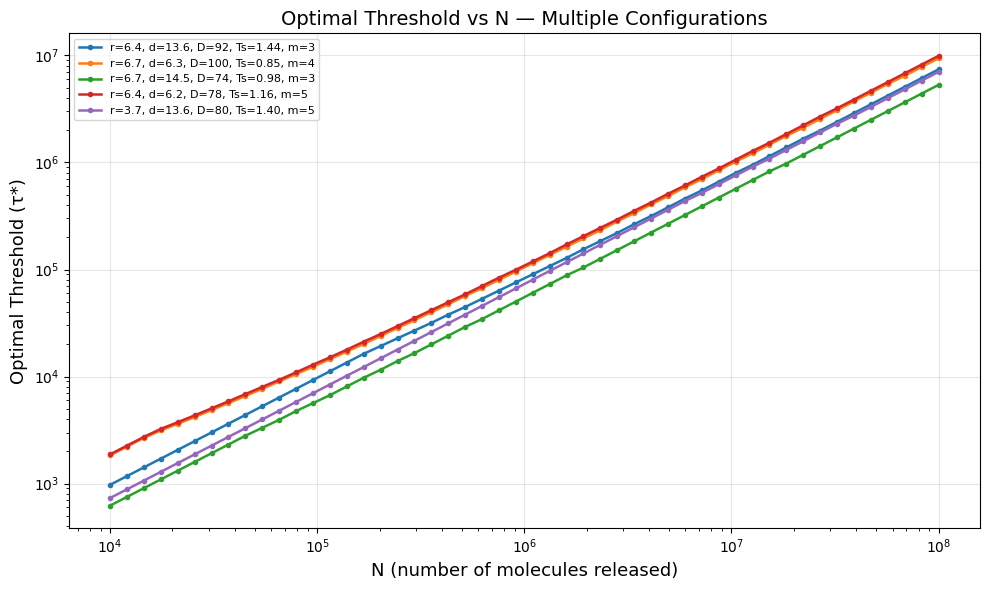

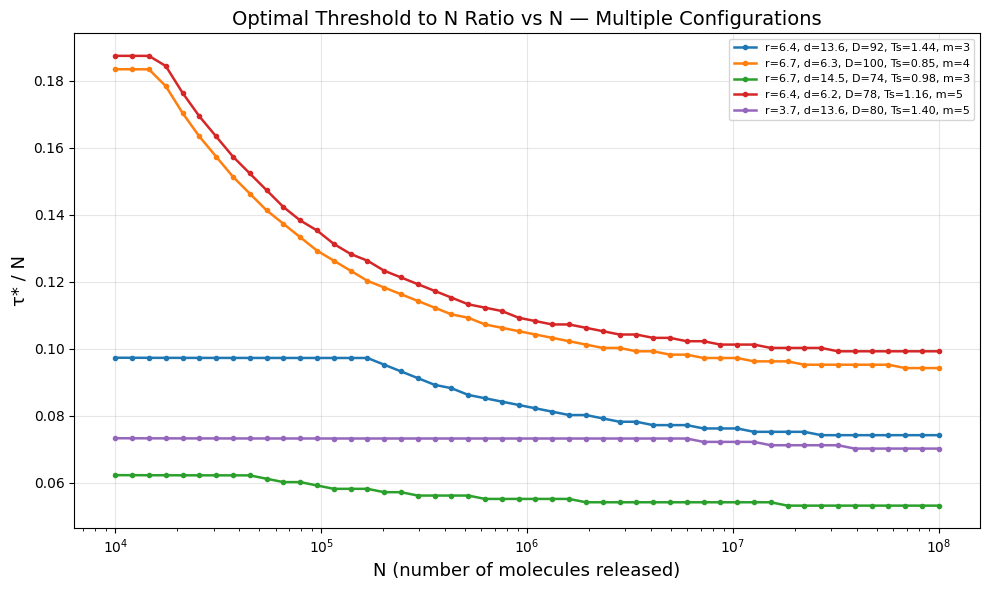

In [20]:
def generate_random_params(seed):
    """
    Generates a reproducible dictionary of physical and system parameters 
    for the molecular communication simulation using a random seed.
    """
    np.random.seed(seed)
    
    params = {
        'mem_len': np.random.randint(low=3, high=7),
        'N': int(10**np.random.uniform(low=5, high=6.5)),
        'radius': np.random.uniform(low=3.0, high=7.0),
        'distance': np.random.uniform(low=5.0, high=15.0),
        'diffusionCoef': np.random.uniform(low=50.0, high=100.0),
        'Ts': np.random.uniform(low=0.5, high=2.0)
    }
    
    return params

num_configs = 5

# Plot 1: Optimal Threshold vs N for multiple configs
fig, ax1 = plt.subplots(figsize=(10, 6))

for seed in range(num_configs):
    params = generate_random_params(seed)
    
    N_values = np.logspace(4, 8, 50).astype(int)
    
    optimal_thresholds = []
    
    for N in N_values:
        th_range = np.linspace(1, N * 0.5, 500)
        bers = [bit_error_rate(params['mem_len'], th, N, params['radius'], params['distance'],
                               params['diffusionCoef'], params['Ts']) for th in th_range]
        opt_i = np.argmin(bers)
        optimal_thresholds.append(th_range[opt_i])
    
    label = f"r={params['radius']:.1f}, d={params['distance']:.1f}, D={params['diffusionCoef']:.0f}, Ts={params['Ts']:.2f}, m={params['mem_len']}"
    ax1.plot(N_values, optimal_thresholds, '-o', markersize=3, linewidth=1.8, label=label)

ax1.set_xlabel('N (number of molecules released)', fontsize=13)
ax1.set_ylabel('Optimal Threshold (τ*)', fontsize=13)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_title('Optimal Threshold vs N — Multiple Configurations', fontsize=14)
ax1.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: τ*/N ratio vs N for multiple configs
fig, ax = plt.subplots(figsize=(10, 6))

for seed in range(num_configs):
    params = generate_random_params(seed)
    
    N_values = np.logspace(4, 8, 50).astype(int)
    
    ratios = []
    for N in N_values:
        th_range = np.linspace(1, N * 0.5, 500)
        bers = [bit_error_rate(params['mem_len'], th, N, params['radius'], params['distance'],
                               params['diffusionCoef'], params['Ts']) for th in th_range]
        opt_i = np.argmin(bers)
        ratios.append(th_range[opt_i] / N)
    
    label = f"r={params['radius']:.1f}, d={params['distance']:.1f}, D={params['diffusionCoef']:.0f}, Ts={params['Ts']:.2f}, m={params['mem_len']}"
    ax.plot(N_values, ratios, '-o', markersize=3, linewidth=1.8, label=label)

ax.set_xlabel('N (number of molecules released)', fontsize=13)
ax.set_ylabel('τ* / N', fontsize=13)
ax.set_xscale('log')
ax.set_title('Optimal Threshold to N Ratio vs N — Multiple Configurations', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()
